# **Dataset Loading and Preprocessing**

In [ ]:
from pathlib import Path
import pyarrow.dataset as ds
import pyarrow.compute as pc
import pandas as pd

DATA_DIR = Path('../data/raw/wildchat')
parquet_files = sorted(DATA_DIR.glob('*.parquet'))
print(f'Found {len(parquet_files)} parquet files in {DATA_DIR.resolve()}')

# Use Arrow dataset API for efficient column projection + filtering
dataset = ds.dataset([str(p) for p in parquet_files], format='parquet')

table = dataset.to_table()
df = table.to_pandas(types_mapper=pd.ArrowDtype)

print('Rows:', len(df))
print('Columns:', df.columns.tolist())
df.head(2)


Found 14 parquet files in /Users/humaid/Documents/University/Sem 4/SMM/Assignment_1/data/raw/wildchat
Rows: 837989
Columns: ['conversation_hash', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted', 'state', 'country', 'hashed_ip', 'header']


,conversation_hash,model,timestamp,conversation,turn,language,openai_moderation,detoxify_moderation,toxic,redacted,state,country,hashed_ip,header
0,c9ec5b440fbdd2a269333dd241f32f64,gpt-4-0314,2023-04-09 00:02:53+00:00,[{'content': 'Hey there! Are you familiar with...,1,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.00020589135237969458, '...",False,False,Texas,United States,22fd87ba9b98f3d379b23c7b52961f2d4a8505127e58b3...,"{'accept-language': 'en-US,en;q=0.9,es;q=0.8',..."
1,34f1581760df304d539e2fe4653b40d3,gpt-4-0314,2023-04-09 00:03:20+00:00,[{'content': 'Crea una imagen de una mujer cor...,2,Spanish,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.007170863449573517, 'in...",False,False,A Coruña,Spain,58369722cd0bdf7fc027a67491ba65b74576df6994c36c...,"{'accept-language': 'es-ES,es;q=0.9,en;q=0.8',..."


In [ ]:
# Collapse model variants into broad families
model_str = df['model'].astype('string').str.lower()

df['model_family'] = 'other'
df.loc[model_str.str.contains(r'^gpt-3\.5-turbo', na=False), 'model_family'] = 'gpt-3.5-turbo'
df.loc[model_str.str.contains(r'^gpt-4', na=False), 'model_family'] = 'gpt-4'

df['model_family'].value_counts(dropna=False)
df['model'] = df['model_family']


# **Research Question 1: What latent prompt topics emerge in WildChat, and how does the topic distribution of U.S. users differ from that of users in the rest of the world?**

## Topic distribution comparison (US vs non-US) using TF-IDF + KMeans

## Imports and Constants

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans
import numpy as np
import pandas as pd
import json
import ast
from collections.abc import Mapping

US_COUNTRY_ALIASES = {'US', 'USA', 'UNITED STATES', 'UNITED STATES OF AMERICA'}

## Helper Functions for Conversation Parsing

In [ ]:
def _to_python_turns(turns):
    if hasattr(turns, "as_py"):
        try:
            turns = turns.as_py()
        except Exception:
            pass

    if isinstance(turns, str):
        s = turns.strip()
        if not s:
            return []
        try:
            turns = json.loads(s)
        except Exception:
            try:
                turns = ast.literal_eval(s)
            except Exception:
                return []

    if isinstance(turns, tuple):
        turns = list(turns)
    elif hasattr(turns, "tolist") and not isinstance(turns, list):
        try:
            turns = turns.tolist()
        except Exception:
            pass

    return turns if isinstance(turns, list) else []

def extract_user_text(turns):
    turns = _to_python_turns(turns)
    out = []
    for t in turns:
        if hasattr(t, "as_py"):
            try:
                t = t.as_py()
            except Exception:
                continue
        if not isinstance(t, Mapping):
            continue
        if str(t.get("role", "")).lower() != "user":
            continue
        txt = t.get("content", "")
        if isinstance(txt, str):
            txt = txt.strip()
            if txt:
                out.append(txt)
    return out

## Build English Prompt-Level Dataset

In [ ]:
records = []
for row in df[['conversation_hash', 'language', 'country', 'conversation']].itertuples(index=False, name=None):
    conv_hash, language, country, conversation = row

    lang = "" if pd.isna(language) else str(language).strip().lower()
    if lang != "english":
        continue

    c = "" if pd.isna(country) else str(country).strip().upper()
    is_us = c in US_COUNTRY_ALIASES

    user_prompts = extract_user_text(conversation)
    for p in user_prompts:
        p = " ".join(p.split())
        if p:
            records.append((conv_hash, is_us, p[:1000]))

df_english = pd.DataFrame(records, columns=['conversation_hash', 'is_us', 'prompt_text_short'])
print("English user prompts:", len(df_english))

## TF-IDF Vectorization and KMeans Topic Modeling

In [ ]:
# Sample for speed
N_SAMPLE = 120000
work = df_english.copy()
if len(work) > N_SAMPLE:
    work = work.sample(N_SAMPLE, random_state=42)

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.6,
    max_features=40000
)
X = vectorizer.fit_transform(work['prompt_text_short'])

n_topics = 12
kmeans = MiniBatchKMeans(n_clusters=n_topics, random_state=42, batch_size=4096, n_init='auto')
work['topic_id'] = kmeans.fit_predict(X)

## Topic Keyword Extraction and Display

In [ ]:
terms = np.array(vectorizer.get_feature_names_out())
topic_keywords = {}
for i, centroid in enumerate(kmeans.cluster_centers_):
    top = centroid.argsort()[-10:][::-1]
    topic_keywords[i] = ', '.join(terms[top])

topic_df = pd.DataFrame({'topic_id': list(topic_keywords.keys()), 'keywords': list(topic_keywords.values())})
for i in range(12):
    print(f"Topic {i}: {topic_df.loc[topic_df['topic_id'] == i, 'keywords'].iloc[0]}")


English user prompts: 1008570
Topic 0: just, rewrite, player, like, using, female, day, base, make, girl
Topic 1: people, make, house, history, scenario, dialogues, world, comedy, china, write
Topic 2: natsuki, monika, sayori, yuri, message, hey, make, clubroom, mc, just
Topic 3: know, don, args, don know, memory, want, key, like, let know, don change
Topic 4: answer, sentence, questions, question, test, help, need, ask, correct, following
Topic 5: planet, freedom planet, naruto, freedom, characters, lilac, react, art, planet characters, generate etsy
Topic 6: detailed, description, detailed description, ar, description scene, prompt, ai, scene, midjourney, structure
Topic 7: code, import, int, file, value, const, string, self, data, error
Topic 8: tell, like tell, research, like, working, computer, tell story, guide, story, travel guide
Topic 9: hi, make, use, list, hello, 10, explain, following, continue, translate
Topic 10: write, story, write story, vs, script, write follow, write 

## Naming the clustered labels

In [36]:
# Suggested manual labels for your 12 topics
topic_name_map = {
    0: "Creative Rewriting & Persona Prompts",
    1: "Creative Worldbuilding & History Scenarios",
    2: "Anime/Game Roleplay (DDLC-style)",
    3: "Troubleshooting, Memory & Preference Edits",
    4: "Q&A, Tests, and Answer Checking",
    5: "Fandom/Character Reaction & Niche Creative Requests",
    6: "Image Generation Prompt Engineering",
    7: "Programming & Debugging",
    8: "Advice, Research & Informational Writing",
    9: "General Assistant Tasks (Lists/Explain/Translate)",
    10: "Story/Script/Article Writing",
    11: "General Knowledge & Meaning Questions"
}

# Add labels to topic_df
topic_df['topic_name'] = topic_df['topic_id'].map(topic_name_map)

# View mapping table
topic_df_labeled = topic_df[['topic_id', 'topic_name', 'keywords']].sort_values('topic_id')
display(topic_df_labeled)

# If you already have prompt-level assignments in `work`, attach readable names there too
work['topic_name'] = work['topic_id'].map(topic_name_map)


,topic_id,topic_name,keywords
0,0,Creative Rewriting & Persona Prompts,"just, rewrite, player, like, using, female, da..."
1,1,Creative Worldbuilding & History Scenarios,"people, make, house, history, scenario, dialog..."
2,2,Anime/Game Roleplay (DDLC-style),"natsuki, monika, sayori, yuri, message, hey, m..."
3,3,"Troubleshooting, Memory & Preference Edits","know, don, args, don know, memory, want, key, ..."
4,4,"Q&A, Tests, and Answer Checking","answer, sentence, questions, question, test, h..."
5,5,Fandom/Character Reaction & Niche Creative Req...,"planet, freedom planet, naruto, freedom, chara..."
6,6,Image Generation Prompt Engineering,"detailed, description, detailed description, a..."
7,7,Programming & Debugging,"code, import, int, file, value, const, string,..."
8,8,"Advice, Research & Informational Writing","tell, like tell, research, like, working, comp..."
9,9,General Assistant Tasks (Lists/Explain/Translate),"hi, make, use, list, hello, 10, explain, follo..."


## Wordcloud to showcase clusters

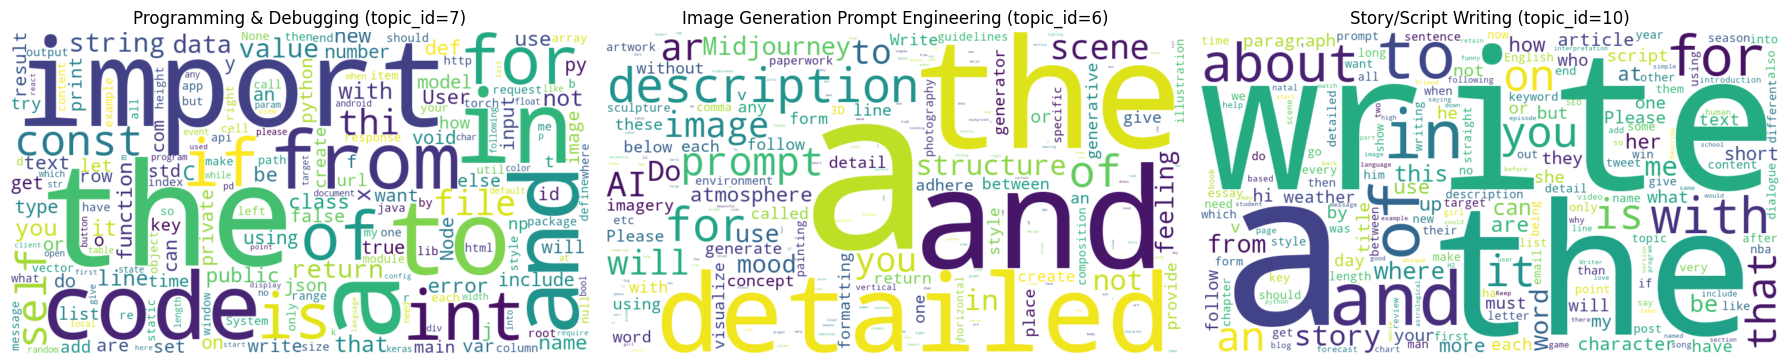

In [40]:
# Word clouds for 3 selected topics:
# - Programming & Debugging (topic_id=7)
# - Image Generation Prompt Engineering (topic_id=6)
# - Story/Script Writing (topic_id=10)

from wordcloud import WordCloud
import matplotlib.pyplot as plt

selected_topics = {
    7: "Programming & Debugging",
    6: "Image Generation Prompt Engineering",
    10: "Story/Script Writing"
}

# Use whichever text column exists
text_col = 'prompt_text_short' if 'prompt_text_short' in work.columns else 'prompt_text'

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (tid, title) in zip(axes, selected_topics.items()):
    text_blob = " ".join(work.loc[work['topic_id'] == tid, text_col].dropna().astype(str).tolist())

    if not text_blob.strip():
        ax.axis('off')
        ax.set_title(f"{title}\n(no text found)")
        continue

    wc = WordCloud(
        width=900,
        height=500,
        background_color='white',
        stopwords='english',  # optional, works in newer wordcloud versions
        collocations=False,
        max_words=200
    ).generate(text_blob)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f"{title} (topic_id={tid})", fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
#Compare topic proportions between US and non-US
topic_share = (
    work.groupby(['is_us', 'topic_id']).size()
    .rename('count')
    .reset_index()
)
topic_share['group_total'] = topic_share.groupby('is_us')['count'].transform('sum')
topic_share['share'] = topic_share['count'] / topic_share['group_total']

pivot_share = topic_share.pivot(index='topic_id', columns='is_us', values='share').fillna(0)
pivot_share.columns = ['non_us_share', 'us_share']
pivot_share['us_minus_nonus'] = pivot_share['us_share'] - pivot_share['non_us_share']
pivot_share = pivot_share.sort_values('us_minus_nonus', ascending=False).reset_index()

result = pivot_share.merge(topic_df, on='topic_id', how='left')
result[['topic_id','topic_name', 'keywords', 'us_share', 'non_us_share', 'us_minus_nonus']].head(12)


,topic_id,topic_name,keywords,us_share,non_us_share,us_minus_nonus
0,2,Anime/Game Roleplay (DDLC-style),"natsuki, monika, sayori, yuri, message, hey, m...",0.072861,0.009967,0.062893
1,0,Creative Rewriting & Persona Prompts,"just, rewrite, player, like, using, female, da...",0.055826,0.015381,0.040445
2,11,General Knowledge & Meaning Questions,"does, like, mean, fish, time, story, look, loo...",0.048848,0.025005,0.023844
3,4,"Q&A, Tests, and Answer Checking","answer, sentence, questions, question, test, h...",0.038731,0.032242,0.006489
4,5,Fandom/Character Reaction & Niche Creative Req...,"planet, freedom planet, naruto, freedom, chara...",0.012189,0.011447,0.000742
5,1,Creative Worldbuilding & History Scenarios,"people, make, house, history, scenario, dialog...",0.012829,0.015347,-0.002518
6,8,"Advice, Research & Informational Writing","tell, like tell, research, like, working, comp...",0.005363,0.008511,-0.003147
7,3,"Troubleshooting, Memory & Preference Edits","know, don, args, don know, memory, want, key, ...",0.010696,0.013959,-0.003263
8,10,Story/Script/Article Writing,"write, story, write story, vs, script, write f...",0.041565,0.066342,-0.024777
9,7,Programming & Debugging,"code, import, int, file, value, const, string,...",0.023464,0.055744,-0.032280


## Comparison Chart  

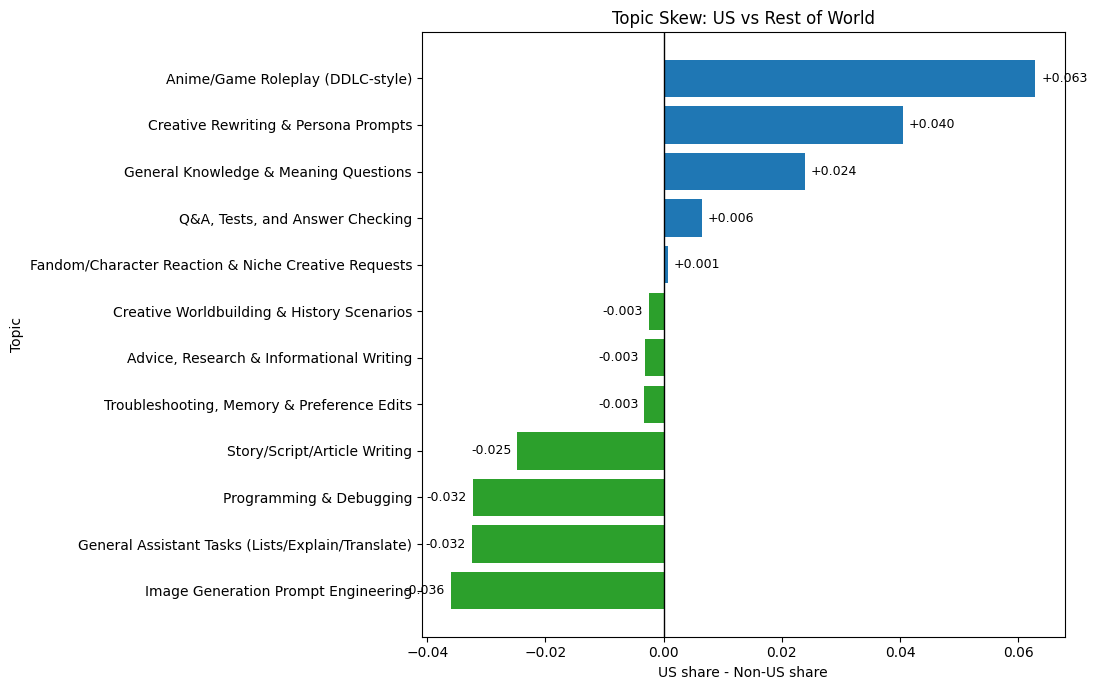

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plot_df = result[['topic_name', 'us_minus_nonus', 'us_share', 'non_us_share']].copy()
plot_df = plot_df.sort_values('us_minus_nonus', ascending=True)

plt.figure(figsize=(11, 7))
colors = plot_df['us_minus_nonus'].apply(lambda x: '#1f77b4' if x >= 0 else '#2ca02c')  # US blue, Non-US green
plt.barh(plot_df['topic_name'], plot_df['us_minus_nonus'], color=colors)

plt.axvline(0, color='black', linewidth=1)
plt.xlabel('US share - Non-US share')
plt.ylabel('Topic')
plt.title('Topic Skew: US vs Rest of World')

# optional labels
for i, v in enumerate(plot_df['us_minus_nonus']):
    plt.text(v + (0.001 if v >= 0 else -0.001), i, f"{v:+.3f}",
             va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()


# **Research Question 2: Do GPT-3.5 and GPT-4 differ in language mix (i.e.,the distribution of conversation languages), and is Chi-nese relatively more prevalent in GPT-3.5 conversations?**

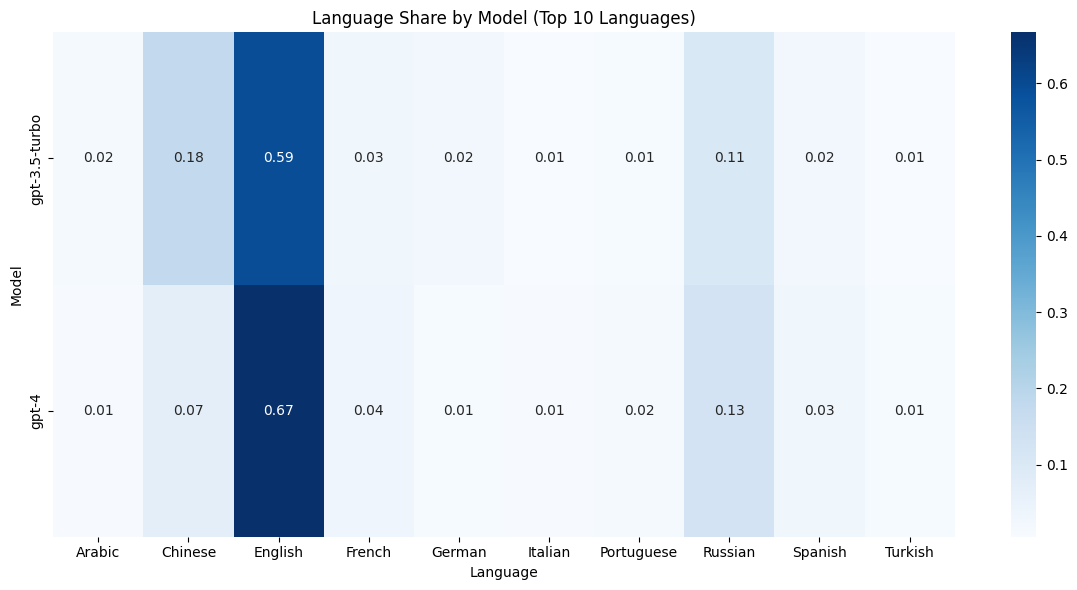

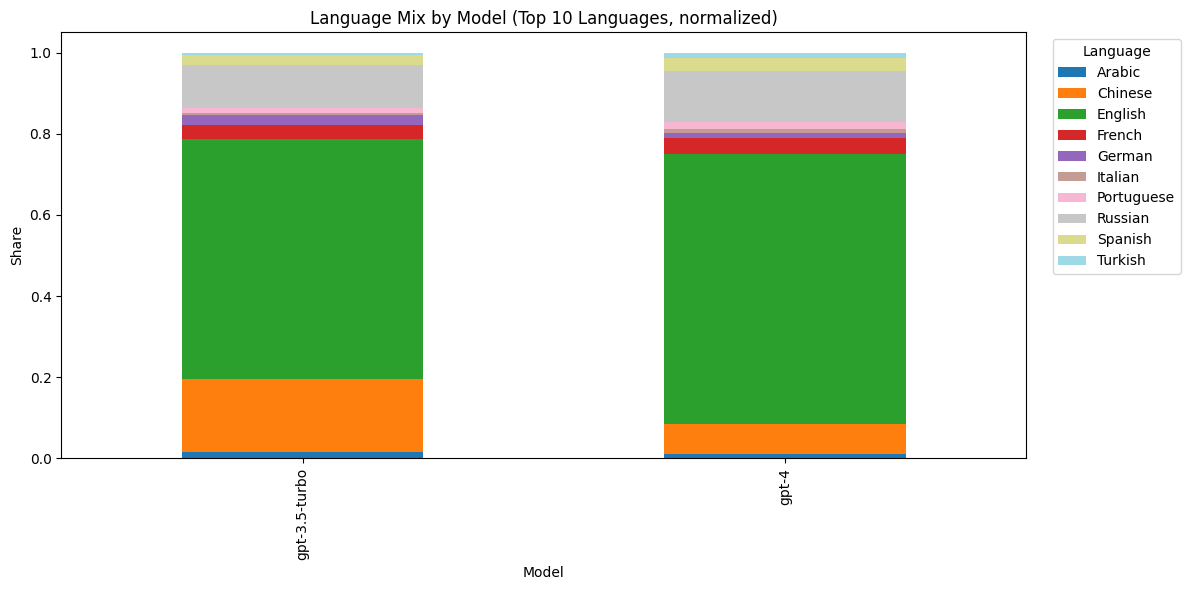

In [46]:
# Do model versions differ in language mix?
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Minimal prep
lang_df = df[['model', 'language']].copy()
lang_df['model'] = lang_df['model'].astype('string').str.strip()
lang_df['language'] = lang_df['language'].astype('string').str.strip()
lang_df = lang_df.dropna(subset=['model', 'language'])
lang_df = lang_df[(lang_df['model'] != '') & (lang_df['language'] != '')].copy()

# Optional: keep top-K models by volume to reduce clutter
TOP_K_MODELS = 8
top_models = lang_df['model'].value_counts().head(TOP_K_MODELS).index
lang_df = lang_df[lang_df['model'].isin(top_models)].copy()

# 2) Top 10 languages globally (within filtered models)
top10_langs = lang_df['language'].value_counts().head(10).index
plot_df = lang_df[lang_df['language'].isin(top10_langs)].copy()

# 3) Counts + shares
counts = (
    plot_df.groupby(['model', 'language'])
    .size()
    .rename('count')
    .reset_index()
)

totals = counts.groupby('model', as_index=False)['count'].sum().rename(columns={'count': 'model_total_top10'})
counts = counts.merge(totals, on='model', how='left')
counts['share'] = counts['count'] / counts['model_total_top10']


# 4) Heatmap: model x language (share)
heat = counts.pivot(index='model', columns='language', values='share').fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="Blues")
plt.title("Language Share by Model (Top 10 Languages)")
plt.xlabel("Language")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

# 5) 100% stacked bar: language composition per model
stack = heat.copy()
stack = stack.reindex(index=stack.sum(axis=1).sort_values(ascending=False).index)

ax = stack.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
ax.set_title("Language Mix by Model (Top 10 Languages, normalized)")
ax.set_xlabel("Model")
ax.set_ylabel("Share")
ax.legend(title="Language", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Statistical Inference to show Chinese language is used more in GPT-3.5 turbo

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

# 1) Reduce to two model buckets (or use your consolidated labels if you already have them) ----
keep_models = ['gpt-3.5-turbo', 'gpt-4']
df2 = lang_df[lang_df['model'].isin(keep_models)].copy()

# 2) Build 2x2 table: model x (Chinese vs not Chinese) ----
df2['is_chinese'] = (df2['language'].str.lower() == 'chinese')

tab = pd.crosstab(df2['model'], df2['is_chinese'])
# Ensure both columns exist
tab = tab.reindex(columns=[True, False], fill_value=0)
tab.columns = ['Chinese', 'Not_Chinese']
print(tab)

# 3) Two-proportion z-test (GPT-3.5 vs GPT-4 on Chinese share) ----
count = np.array([tab.loc['gpt-3.5-turbo', 'Chinese'],
                  tab.loc['gpt-4', 'Chinese']])

nobs  = np.array([tab.loc['gpt-3.5-turbo'].sum(),
                  tab.loc['gpt-4'].sum()])

zstat, pval = proportions_ztest(count, nobs, alternative='two-sided')
p1, p2 = count / nobs
diff = p1 - p2

# 95% CI for difference in proportions (Wald CI)
se = np.sqrt(p1*(1-p1)/nobs[0] + p2*(1-p2)/nobs[1])
ci_low, ci_high = diff - 1.96*se, diff + 1.96*se

print("\nTwo-proportion z-test (Chinese share):")
print(f"p(GPT-3.5)={p1:.4f}, p(GPT-4)={p2:.4f}, diff={diff:.4f}")
print(f"z={zstat:.3f}, p={pval:.3e}, 95% CI=[{ci_low:.4f}, {ci_high:.4f}]")

# ---- 4) Effect size (phi) for 2x2 table + chi-square check ----
chi2, p_chi, dof, expected = chi2_contingency(tab.values, correction=False)
N = tab.values.sum()
phi = np.sqrt(chi2 / N)   # phi coefficient for 2x2 (same as Cramer's V for 2x2)

print("\nChi-square (2x2) + effect size:")
print(f"chi2={chi2:.3f}, dof={dof}, p={p_chi:.3e}, phi={phi:.4f}")

# Optional: check expected counts (rule-of-thumb)
min_expected = expected.min()
print(f"Min expected cell count: {min_expected:.2f}")


               Chinese  Not_Chinese
model                              
gpt-3.5-turbo   104735       519119
gpt-4            14567       199568

Two-proportion z-test (Chinese share):
p(GPT-3.5)=0.1679, p(GPT-4)=0.0680, diff=0.0999
z=114.101, p=0.000e+00, 95% CI=[0.0984, 0.1013]

Chi-square (2x2) + effect size:
chi2=13018.934, dof=1, p=0.000e+00, phi=0.1246
Min expected cell count: 30485.76


Chinese language is more used for gpt 3.5 turbo models